In [8]:
import numpy as np
import matplotlib.pyplot as plt
from Utilities import extractor
import uproot
import awkward as ak    

x_MH25=extractor("Dati/Tprime_tAq_1800_MH25_LH_2017.root", "Events")


file=uproot.open("Dati/Tprime_tAq_1800_MH25_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]

#Filtriamo i dati

mask = ak.flatten(Fatjet_isMatchedWithA) == 1
x_filtered = x_MH25[mask]



/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


In [9]:
from scipy.special import voigt_profile
from scipy.optimize import curve_fit
from iminuit import Minuit
from iminuit.cost import LeastSquares

x_plot=list(x_filtered)
x_plot.sort()

def voigt(x, norm, mu, sigma, gamma):
    return voigt_profile(x-mu, sigma, gamma) * norm

bin_counts, bin_edges = np.histogram(x_plot, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_plot) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_plot) * bin_width) # Errore standard per i dati binned

ls_voigt=LeastSquares(bin_centers, bin_densities, yerr, model=voigt)

m_voigt=Minuit(ls_voigt,  norm=1, mu=50, sigma=5, gamma=1)
m_voigt.limits["mu"]= (10, 40)
m_voigt.limits["sigma"]= (0.1, 20)
m_voigt.limits["gamma"]= (0.01, 10)
m_voigt.migrad()








┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3166 (χ²/ndof = 68.8)      │              Nfcn = 177              │
│ EDM = 5.63e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ norm  │   0.951   │   0.004   │            │            │         │         │       │
│ 1 │ mu    │  25.550   │   0.017   │            │            │   10    │   40    │       │
│ 2 │ sigma │   2.844   │   0.023   │            │            │   0.1   │   20    │       │
│ 3 │ gamma │   0.284   │   0.011   │            │            │  0.01   │   10    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────┐
│       │      norm        mu     sigma     gamma │
├───────┼─────────────────────────────────────────┤
│  norm │   1.7e-05  0.003e-3 -0.008e-3  0.003e-3 │
│    mu │  0.003e-3  0.000307  -0.25e-3   0.06e-3 │
│ sigma │ -0.008e-3  -0.25e-3  0.000521  -0.17e-3 │
│ gamma │  0.003e-3   0.06e-3  -0.17e-3  0.000115 │
└───────┴─────────────────────────────────────────┘

In [10]:
import pickle

with open("fit_results.pkl", "wb") as f:
    pickle.dump(m_voigt.values, f)

print(m_voigt.values)

<ValueView norm=0.9508152528989859 mu=25.54969272049765 sigma=2.844057736211518 gamma=0.284418290713378>


((array([  2.54375005,   7.63125038,  12.71875   ,  17.80625153,
          22.89374924,  27.98125076,  33.06874847,  38.15625   ,
          43.24375153,  48.33125305,  53.41875076,  58.50625229,
          63.59375381,  68.68125153,  73.76875305,  78.85624695,
          83.9437561 ,  89.03125   ,  94.11875153,  99.20625305,
         104.29374695, 109.3812561 , 114.46875   , 119.55625916,
         124.64375305, 129.73126221, 134.8187561 , 139.90625   ,
         144.9937439 , 150.08125305, 155.16876221, 160.2562561 ,
         165.34375   , 170.4312439 , 175.51875305, 180.60626221,
         185.6937561 , 190.78125   , 195.8687439 , 200.95625305,
         206.04376221, 211.1312561 , 216.21875   , 221.3062439 ,
         226.39375305, 231.48126221, 236.5687561 , 241.65625   ,
         246.74375916, 251.83125305]),
  array([1.07232265e-04, 1.14150476e-04, 3.38992322e-04, 1.21103277e-02,
         7.68682385e-02, 9.48106178e-02, 4.46224587e-03, 1.23835971e-03,
         4.63520113e-04, 3.66665164

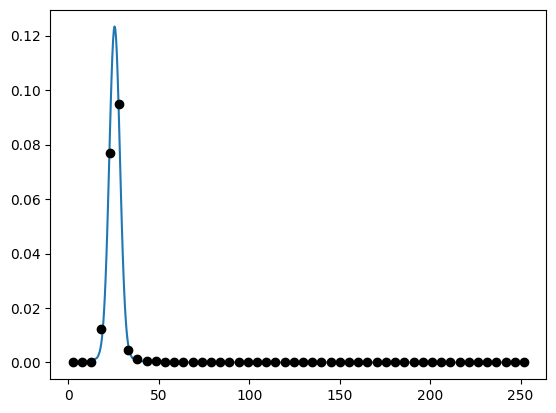

In [12]:
m_voigt.visualize()